# Import Dependencies
**Muhammad Raihan Hassan - 5026231108**

In [5]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to C:\Users\ASUS
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Define Document

In [6]:
sentence2 = """Surabaya: Kota Pahlawan ini telah diakui secara luas sebagai salah satu pelopor utama penerapan konsep Smart City di Indonesia. Pemerintah kota mengedepankan pemanfaatan teknologi informasi untuk memecahkan berbagai permasalahan urban dan melayani warganya.

Layanan publik di Surabaya kini dapat diakses secara daring dengan sangat mudah melalui sistem e-government. Fasilitas Command Center 112 menjadi bukti nyata kesigapan pemerintah kota dalam menangani kondisi darurat warga secara terpusat dan responsif.

Penerapan Smart City ini tidak hanya berfokus semata pada kecanggihan infrastruktur teknologi komunikasi dan jaringan internet. Hal yang lebih penting adalah dampaknya pada peningkatan kualitas hidup, keamanan, dan kebahagiaan warganya sehari-hari.

Kolaborasi yang kuat antara pemerintah, akademisi perguruan tinggi seperti ITS, dan masyarakat menjadi kunci keberhasilan keberlanjutan program digital ini. Ekosistem inovasi di Surabaya diharapkan terus berkembang dan menjadi inspirasi.

Diharapkan, kota-kota lain di Indonesia dapat mereplikasi kesuksesan digitalisasi layanan publik dan integrasi sistem cerdas ini demi kemajuan bangsa.
"""

# Text Preprocessing

In [7]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\ASUS
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print(sent_token2)

['Surabaya: Kota Pahlawan ini telah diakui secara luas sebagai salah satu pelopor utama penerapan konsep Smart City di Indonesia.', 'Pemerintah kota mengedepankan pemanfaatan teknologi informasi untuk memecahkan berbagai permasalahan urban dan melayani warganya.', 'Layanan publik di Surabaya kini dapat diakses secara daring dengan sangat mudah melalui sistem e-government.', 'Fasilitas Command Center 112 menjadi bukti nyata kesigapan pemerintah kota dalam menangani kondisi darurat warga secara terpusat dan responsif.', 'Penerapan Smart City ini tidak hanya berfokus semata pada kecanggihan infrastruktur teknologi komunikasi dan jaringan internet.', 'Hal yang lebih penting adalah dampaknya pada peningkatan kualitas hidup, keamanan, dan kebahagiaan warganya sehari-hari.', 'Kolaborasi yang kuat antara pemerintah, akademisi perguruan tinggi seperti ITS, dan masyarakat menjadi kunci keberhasilan keberlanjutan program digital ini.', 'Ekosistem inovasi di Surabaya diharapkan terus berkembang da

Kode di atas digunakan untuk memecah teks panjang menjadi beberapa kalimat.

Fungsi sent_tokenize() dari NLTK akan membaca teks dan memisahkannya berdasarkan tanda baca seperti titik (.), tanda tanya (?), dan tanda seru (!).

Hasilnya adalah sebuah list yang berisi kalimat-kalimat terpisah, sehingga teks menjadi lebih mudah untuk diproses dan dianalisis pada tahap selanjutnya.

In [9]:
!pip install Sastrawi

Pada kode ini, teks berita terlebih dahulu dipecah menjadi beberapa kalimat menggunakan sent_tokenize(). Setelah itu, setiap kalimat dibersihkan dengan menghapus kata-kata umum (stopwords) Bahasa Indonesia menggunakan library Sastrawi.

Selanjutnya, kalimat yang sudah dibersihkan diubah menjadi bentuk numerik menggunakan metode TF-IDF (Term Frequency-Inverse Document Frequency). Proses ini dilakukan dengan TfidfVectorizer().

TF-IDF memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya. Kata yang sering muncul dalam satu kalimat tetapi jarang muncul di kalimat lain akan memiliki nilai yang lebih tinggi.

Hasil akhirnya berupa matriks TF-IDF yang menunjukkan representasi numerik dari setiap kalimat, sehingga dapat digunakan untuk analisis lanjutan seperti klasifikasi atau pencarian informasi.

In [10]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# Feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# TF-IDF untuk kalimat pertama
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

Tokenized sentences:
Surabaya: Kota Pahlawan ini telah diakui secara luas sebagai salah satu pelopor utama penerapan konsep Smart City di Indonesia.
Pemerintah kota mengedepankan pemanfaatan teknologi informasi untuk memecahkan berbagai permasalahan urban dan melayani warganya.
Layanan publik di Surabaya kini dapat diakses secara daring dengan sangat mudah melalui sistem e-government.
Fasilitas Command Center 112 menjadi bukti nyata kesigapan pemerintah kota dalam menangani kondisi darurat warga secara terpusat dan responsif.
Penerapan Smart City ini tidak hanya berfokus semata pada kecanggihan infrastruktur teknologi komunikasi dan jaringan internet.
Hal yang lebih penting adalah dampaknya pada peningkatan kualitas hidup, keamanan, dan kebahagiaan warganya sehari-hari.
Kolaborasi yang kuat antara pemerintah, akademisi perguruan tinggi seperti ITS, dan masyarakat menjadi kunci keberhasilan keberlanjutan program digital ini.
Ekosistem inovasi di Surabaya diharapkan terus berkembang dan 

Pada bagian ini, nilai TF-IDF yang telah dihitung sebelumnya divisualisasikan menggunakan grafik batang (bar chart).

Data yang digunakan adalah nilai TF-IDF dari kata-kata pada kalimat pertama setelah proses pembersihan (stopwords removal). Setiap kata ditampilkan pada sumbu X, sedangkan nilai TF-IDF ditampilkan pada sumbu Y.

Visualisasi ini membantu kita melihat kata mana yang paling penting dalam suatu kalimat. Semakin tinggi nilai TF-IDF, semakin besar pengaruh kata tersebut dalam kalimat.

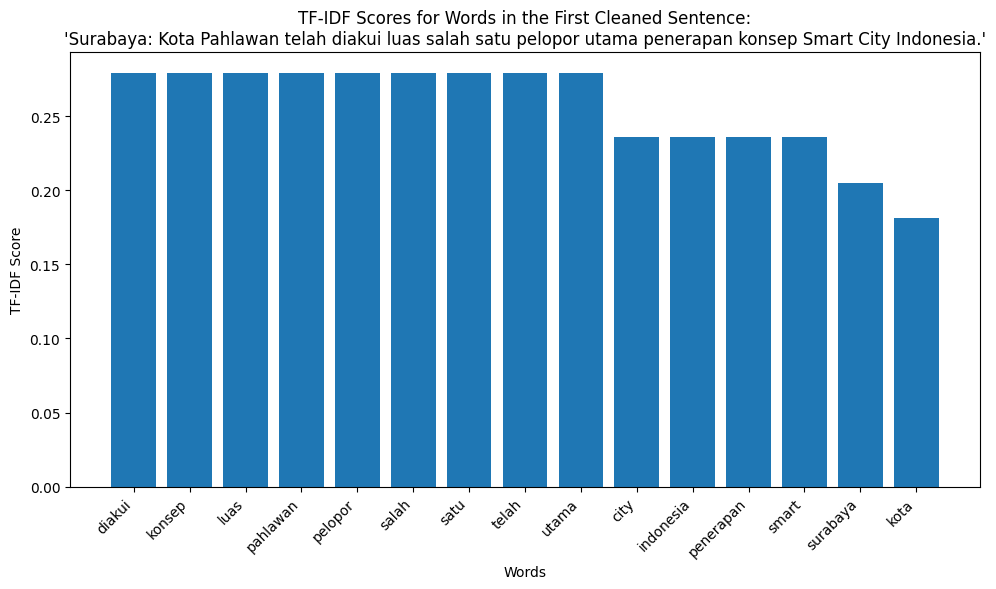

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

In [12]:
# Summarization process
import numpy as np
sentence_scores = np.asarray(features.sum(axis=1)).ravel()
top_n = 3
top_sentence_indices = sentence_scores.argsort()[-top_n:][::-1]
top_sentence_indices.sort()

final_summ = " ".join([sent_token2[i] for i in top_sentence_indices])

# Summarization Result

In [13]:
final_summ

'Fasilitas Command Center 112 menjadi bukti nyata kesigapan pemerintah kota dalam menangani kondisi darurat warga secara terpusat dan responsif. Kolaborasi yang kuat antara pemerintah, akademisi perguruan tinggi seperti ITS, dan masyarakat menjadi kunci keberhasilan keberlanjutan program digital ini. Diharapkan, kota-kota lain di Indonesia dapat mereplikasi kesuksesan digitalisasi layanan publik dan integrasi sistem cerdas ini demi kemajuan bangsa.'